In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/valorant_synthetic_data_raw.csv')

In [3]:
df.head()

,player_id,archetype,adr,kast_percent,first_bloods_per_round,first_deaths_per_round,assists_per_round,clutch_win_rate,survival_rate,trade_percent,headshot_percent,econ_rating,sniper_kill_percent
0,player_1567,Passive Support,127.771530,80.666625,0.083983,0.031096,0.365098,11.136633,42.159445,21.955089,17.512937,71.951646,0.447912
1,player_1681,Passive Support,110.140189,80.393406,0.000000,0.032282,0.372977,16.966892,37.464749,22.424678,23.987830,59.915164,0.000000
2,player_2159,Lurker,153.355195,75.337680,0.057669,0.063496,0.214553,25.277961,35.750426,9.171894,25.406877,83.041346,7.245788
3,player_2762,Lurker,134.708599,71.663029,0.110077,0.035259,0.105504,29.324911,23.670201,6.657268,28.189614,68.858740,14.150363
4,player_3804,Utility-Heavy,121.936649,79.903360,0.053401,0.180187,0.361064,11.871890,28.189863,17.296836,17.711325,52.848317,6.014145


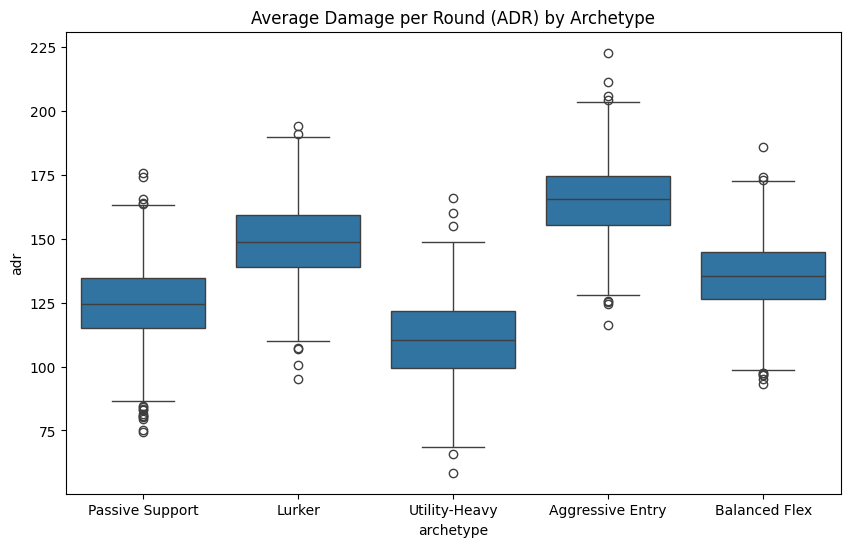

In [9]:
# Plot ADR distribution by archetype
plt.figure(figsize=(10, 6))
sns.boxplot(x='archetype', y='adr', data=df)
plt.title('Average Damage per Round (ADR) by Archetype')
plt.show()
plt.savefig('../visualizations/adr_boxplot.png')
plt.close()

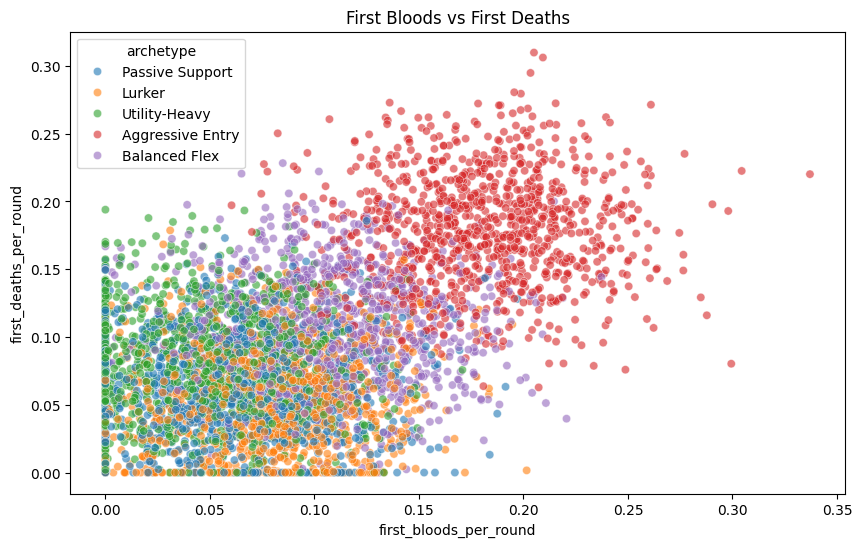

In [10]:
# Plot First Bloods vs First Deaths
plt.figure(figsize=(10, 6))
sns.scatterplot(x='first_bloods_per_round', y='first_deaths_per_round', hue='archetype', data=df, alpha=0.6)
plt.title('First Bloods vs First Deaths')
plt.show()
plt.savefig('../visualizations/fb_vs_fd_scatter.png')
plt.close()

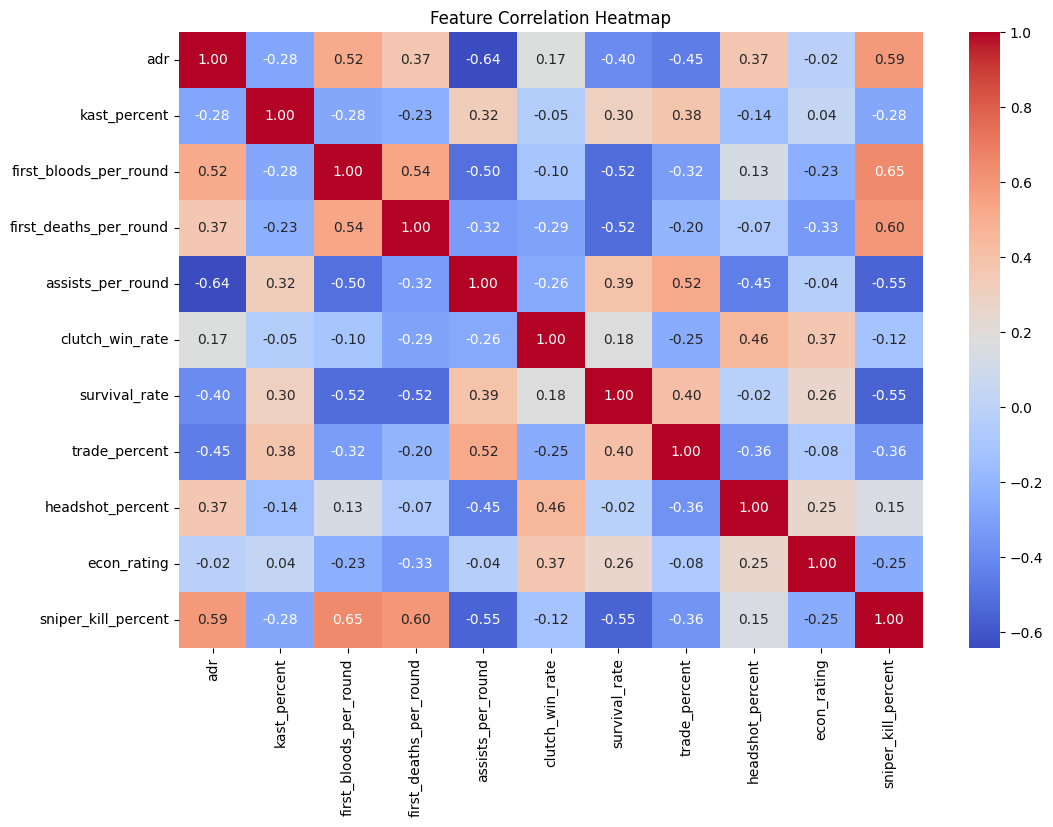

In [11]:
# Plot feature correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()
plt.savefig('../visualizations/correlation_heatmap.png')
plt.close()

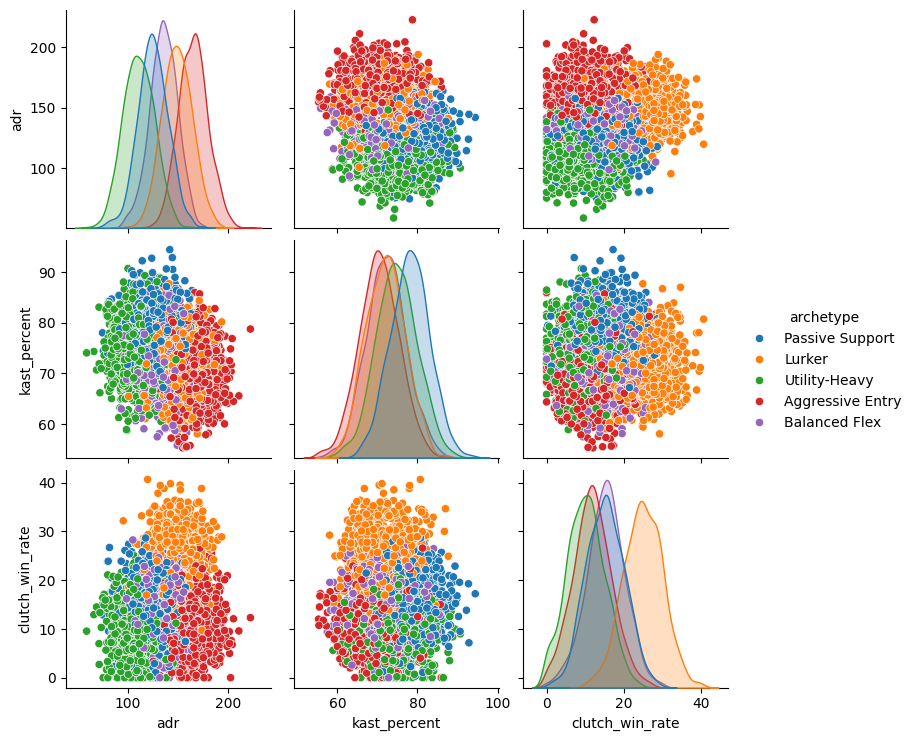

In [12]:
# Plot pairplot for key metrics
key_metrics = ['adr', 'kast_percent', 'clutch_win_rate', 'archetype']
sns.pairplot(df[key_metrics], hue='archetype')
plt.show()
plt.savefig('../visualizations/key_metrics_pairplot.png')
plt.close()

### Data Analysis & Validation Results

Based on the generated visualizations, our synthetic data accurately reflects distinct Valorant playstyles:

* **ADR Boxplot (`adr_boxplot.png`):** We can see clear stratification in damage output. "Aggressive Entry" and "Lurker" archetypes boast the highest average damage, while "Utility-Heavy" players have the lowest, correctly reflecting their supportive role.
* **Aggression Scatter Plot (`fb_vs_fd_scatter.png`):** This perfectly isolates our entry players. The "Aggressive Entry" cluster dominates the top-right quadrant (high first bloods, high first deaths), while "Passive Support" and "Utility-Heavy" are tightly grouped in the bottom-left.
* **Correlation Heatmap (`correlation_heatmap.png`):** The heatmap confirms logical relationships in the data. For example, there is a strong negative correlation between `first_deaths_per_round` and `survival_rate`, and a positive correlation between `adr` and `first_bloods_per_round`.
* **Pairplot (`key_metrics_pairplot.png`):** This proves that our K-Means model will be successful. While no single metric perfectly separates all 5 archetypes, looking at them in multi-dimensional space (like KAST % vs. Clutch Win Rate) shows distinct, recognizable clusters that an unsupervised machine learning algorithm will be able to detect.
